In [14]:
import os
from dotenv import load_dotenv
load_dotenv()

if os.environ['GROQ_API_KEY']:
    print("Groq API Key Set!")
else:
    raise ValueError("Groq API Key is not set!!")

Groq API Key Set!


In [15]:
from langchain_groq import ChatGroq

llm = ChatGroq(model = "openai/gpt-oss-20b")

llm.invoke("Hello!").content    

'Hello! How can I help you today?'

## **LLM PYDANTIC SCHEMA**

In [16]:
from typing import Literal
from pydantic import BaseModel, Field

class llm_schema(BaseModel):
    category : Literal['insta', 'twitter', 'linkedin'] = Field(...,description="Category of the post to generate")
    topic : str = Field(..., description="Topic of the post to generate")

In [17]:
llm_with_schema = llm.with_structured_output(llm_schema)

In [18]:
llm_with_schema.invoke("I want to generate a post for twitter about AI")

llm_schema(category='twitter', topic='AI')

## **STATE SCHEMA**

In [19]:
from typing import TypedDict

class graph_schema(TypedDict):

    input : str
    topic : str
    post : str
    category : str

In [20]:
def decider_node(state : graph_schema) -> graph_schema:

    user_input = state['input']
    result = llm_with_schema.invoke(user_input) #Pydantic Object
    category = result.category
    topic = result.topic
    state['category'] = category
    state['topic'] = topic
    return state

def create_post_insta(state : graph_schema) -> graph_schema:

    topic = state['topic']
    post = llm.invoke(f"Write a instagram post for {topic}. Keep the tone casual & engaging").content
    state['post'] = post
    return {'post': post}

def create_post_twitter(state : graph_schema) -> graph_schema:

    topic = state['topic']
    post = llm.invoke(f"Write a twitter post for {topic}. Keep the tone quick.").content
    state['post'] = post
    return {'post': post}

def create_post_linkedin(state : graph_schema) -> graph_schema:

    topic = state['topic']
    post = llm.invoke(f"Write a linkedin post for {topic}. Keep the tone professional & informative").content
    state['post'] = post
    return {'post': post}

In [21]:
def condition(state : graph_schema)-> str:

    category = state['category']

    if category == 'insta':
        return 'create_post_insta'
    elif category == 'twitter':
        return 'create_post_twitter'
    elif category == 'linkedin':
        return 'create_post_linkedin'
    else:
        raise ValueError('Invalid Category')

In [22]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

graph.add_node("decider", decider_node)
graph.add_node("create_post_insta", create_post_insta)
graph.add_node("create_post_twitter", create_post_twitter)
graph.add_node("create_post_linkedin", create_post_linkedin)

graph.add_edge(START, "decider")
graph.add_conditional_edges("decider", condition, {
    'create_post_insta' : "create_post_insta",
    'create_post_twitter' : "create_post_twitter",
    'create_post_linkedin' : "create_post_linkedin"
})

graph.add_edge("create_post_insta", END)
graph.add_edge("create_post_twitter", END)
graph.add_edge("create_post_linkedin", END)

route_graph = graph.compile()

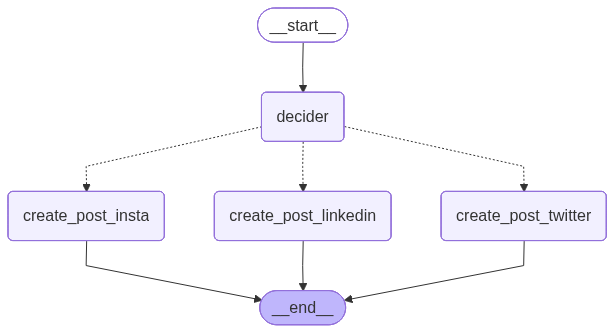

In [23]:
from IPython.display import Image,display

Image(route_graph.get_graph().draw_mermaid_png())

In [29]:
route_graph.invoke(
    {"input":"I want to create a twitter post about AI",
    "topic":"",
    "category":"",
    "post":"",
    }
)

{'input': 'I want to create a twitter post about AI',
 'topic': 'AI',
 'post': '🤖 AI is rewriting the rulebook: faster data crunching, smarter predictions, and a dash of creativity. It’s not just tech—it’s a mindset shift. Ready to level up? 🚀 #AI #TechRevolution #FutureNow',
 'category': 'twitter'}